# Instructions

Welcome to my project ! This project demonstrates how to build and train a simple neural network using TensorFlow and Keras to classify images from the Fashion MNIST dataset.

To test out the model click run time then click run all and wait for a few seconds, youll be prompted to pick a number. Pick a number between 1 and 1000 to see the results, which are displayed at the end of the notebook. Hope you enjoy!



In [27]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Fashion mnist datasat

Contains 60000 images for training and 10000 images for testing

In [28]:
fashion_mnist = keras.datasets.fashion_mnist #accesses fashion mnist ds from keras datasets module
(train_images,train_labels) , (test_images,test_labels) = fashion_mnist.load_data() #splits data sets

In [29]:
# 60000 training images
# each image is 28 pixel length by 28 pixel width
# A pixel is the  smallest controllable element of a picture represented on the screen.
train_images.shape

(60000, 28, 28)

In [30]:
'''
train[0] accesses first image
train[23] row 23 of pixel
train[23][23] column 23 of pixel
uint is unsigned integer ranging from 0-255
0 represents black
255 represents white
pixel ranging in between are shades of gray
194 represents an above average shade of grey
'''

train_images[0,23,23]

np.uint8(194)

In [31]:
'''
represents 10 classes of different clothing items
'''

train_labels[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

In [32]:
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [33]:
print(len(class_names))

10


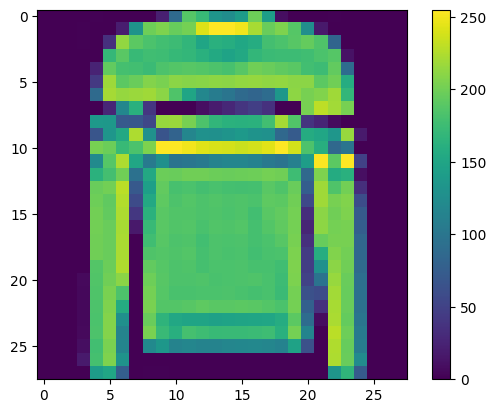

In [34]:
'''
plt.figure(): This creates a new figure, which is like an empty canvas where your plot will be drawn.
plt.imshow(train_images[1]): This is the core command for displaying the image.
plt.colorbar(): This adds a color bar next to the image. Since these are grayscale images, the color bar shows the mapping of pixel intensity values (0-255) to shades of gray. This helps you understand what brightness level corresponds to a particular number.
plt.grid(False): By default, imshow might sometimes display a grid. This command explicitly turns off the grid lines on the plot, making the image clearer.
plt.show(): This command displays the figure with the image, color bar, and no grid.
'''

plt.figure()
plt.imshow(train_images[5])
plt.colorbar()
plt.grid(False)
plt.show()


In [35]:
# Data Preprocessing
'''
Squashing the pixel values between 0 and 1
this helps the model learn faster by faster convegence
Prevents exploding gradients
The model learns the true relationships and patterns within the data, rather than being biased by the raw magnitude of the numbers.
'''

train_images = train_images / 255.0
test_images = test_images / 255.0

In [36]:
'''
Flatten layer converts each image input which is composed of 28 row pixels and 28 column pixels to 1D array
Hence one image with grayscale pixels will converted to 1D array making them accessed from a single list
it does this by (28*28) = 784 items in a single raw
this is as densely conneceted layers require data to be in 1 D array format
output layer has 10 neurons since there are 10 classes of clothing
'''

model = keras.Sequential([keras.layers.Flatten(input_shape = (28,28)),#input layer
                          keras.layers.Dense(128,activation='relu'),#hidden layer
                          keras.layers.Dense(10,activation='softmax')])#output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
'''
flatten() converts 2D arrays to 1D arrays
2D - Concept: A 2D array is like a table or a grid of values, organized into rows and columns. You need two indices to pinpoint any element: one for its row and one for its column.
'''
flattened_1d_array=train_images[0].flatten()
flattened_1d_array.shape

(784,)

In [38]:
import numpy as np

# Create a sample 2D array (e.g., a 3x3 'image')
sample_2d_array = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print("Original 2D Array (shape:", sample_2d_array.shape, "):")
print(sample_2d_array)

# Flatten the 2D array into a 1D array
flattened_1d_array = sample_2d_array.flatten()

print("\nFlattened 1D Array (shape:", flattened_1d_array.shape, "):")
print(flattened_1d_array)

print("\nNotice how the elements are arranged row by row into a single sequence.")

Original 2D Array (shape: (3, 3) ):
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Flattened 1D Array (shape: (9,) ):
[1 2 3 4 5 6 7 8 9]

Notice how the elements are arranged row by row into a single sequence.


As you can see, the `flatten()` method took the elements of the 2D array, starting from the first row, then the second, and so on, and laid them out sequentially into a single 1D array. This is precisely what the `keras.layers.Flatten` layer does to your 28x28 image, resulting in a 784-element 1D vector.

In [39]:
'''
compile configures the N.Network
defines the optimizer, algorithm how parameters(weights and biases) will be tweaked
loss = how loss will be calculated in this case is for categorical
'''

model.compile(optimizer = 'adam', loss ='sparse_categorical_crossentropy', metrics =['accuracy'])

In [40]:
'''
monitor training accuracy
our goal(mode) is to maximize it
tolerance level at 3
'''

import tensorflow
from tensorflow.keras.callbacks import EarlyStopping
early_stopping =EarlyStopping(monitor= 'accuracy',mode='max',patience=3,verbose=1,restore_best_weights =True,min_delta = 0.0001)



In [41]:
model.fit(train_images,train_labels,epochs=10,callbacks=[early_stopping])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7745 - loss: 0.6455
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8620 - loss: 0.3845
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8795 - loss: 0.3312
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8863 - loss: 0.3048
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8931 - loss: 0.2918
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8980 - loss: 0.2764
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9002 - loss: 0.2674
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9050 - loss: 0.2513
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9092 - loss: 0.2430
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9119 - loss: 0.2361
Restoring model weights from the end of the best epoch: 10.


In [42]:
'''
model.evaluate()
passes testing data on learned parameters
then calculates loss
'''
test_loss, test_acc = model.evaluate(test_images,test_labels,verbose =1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8782 - loss: 0.3395


# Conclusion

Model is overfitted, since accuracy rate on test data is lower than training data.
I notice that when i create a new model instance ,and run it on less epochs the accuracy improves and the model doesn't overfit.

In [43]:
models_predictions = model.predict(test_images[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


In [44]:
'''
size of testing data
'''

test_images.shape

(10000, 28, 28)

In [45]:
print(models_predictions)

[[1.1320958e-07 2.8484468e-10 7.8843387e-10 7.7460266e-10 6.3186818e-08
  9.3231596e-05 2.2705748e-08 7.9807667e-03 5.6913734e-08 9.9192578e-01]
 [4.9731003e-05 2.4294961e-15 9.8481202e-01 2.0993053e-10 1.4390089e-02
  5.5408786e-14 7.4801641e-04 4.0988305e-15 1.6860683e-07 5.0188644e-14]
 [1.6798814e-10 1.0000000e+00 7.3366426e-12 6.6540817e-09 1.3472659e-10
  1.0340074e-18 5.2000564e-09 2.8795967e-25 3.5845552e-11 2.2067154e-20]
 [5.1829545e-08 9.9998784e-01 1.1359561e-08 1.1646300e-05 6.9884358e-08
  1.1167981e-14 3.4970918e-07 2.5110382e-21 1.7952244e-11 3.5380907e-15]
 [2.1275003e-01 7.5387705e-09 4.2417930e-03 5.7550706e-04 1.8585268e-03
  4.5955627e-08 7.8055733e-01 1.1839539e-08 1.6778336e-05 3.7431400e-09]]


In [46]:
print(np.argmax(models_predictions[0]))

9


Clothing 1 is predicted to be Ankle boot by the model with a probability of (99.19)%


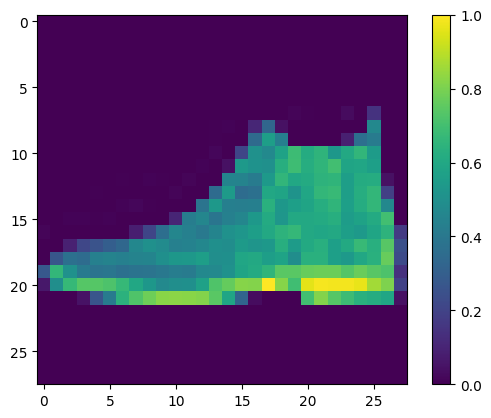

Clothing 2 is predicted to be Pullover by the model with a probability of (98.48)%


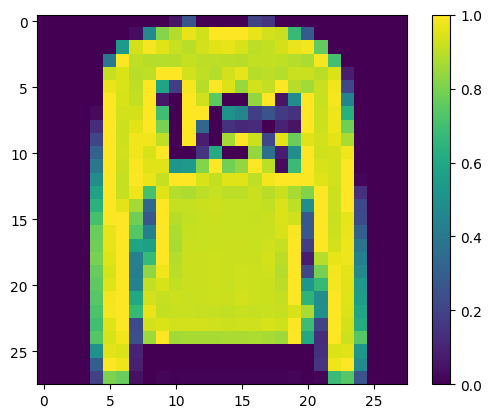

Clothing 3 is predicted to be Trouser by the model with a probability of (100.00)%


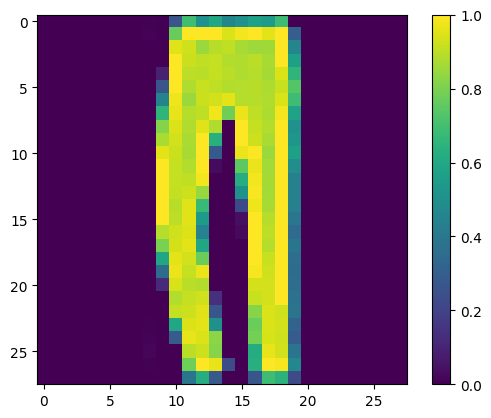

Clothing 4 is predicted to be Trouser by the model with a probability of (100.00)%


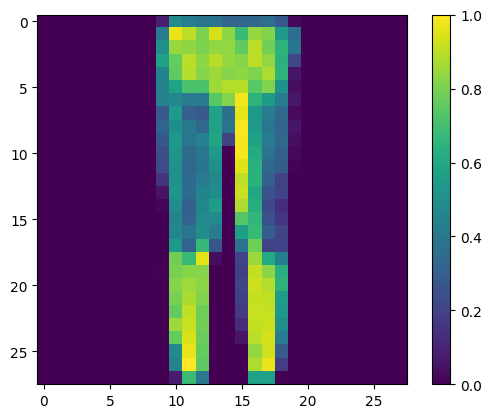

Clothing 5 is predicted to be Shirt by the model with a probability of (78.06)%


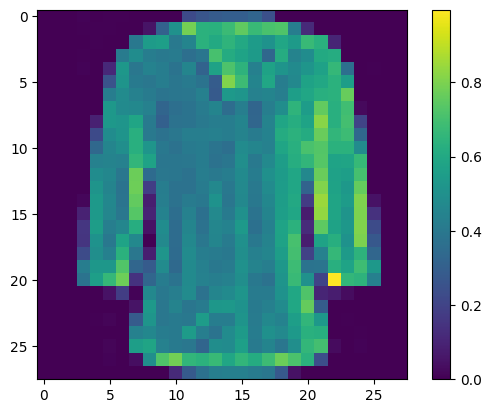

In [47]:
for index,prediction in enumerate(models_predictions,1):
  class_id = np.argmax(prediction)
  probability=prediction[class_id]
  print(f"Clothing {index} is predicted to be {class_names[class_id]} by the model with a probability of ({100*probability:.2f})%")
  plt.figure()
  plt.imshow(test_images[index-1])
  plt.colorbar()
  plt.grid(False)
  plt.show()

Pick a number: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


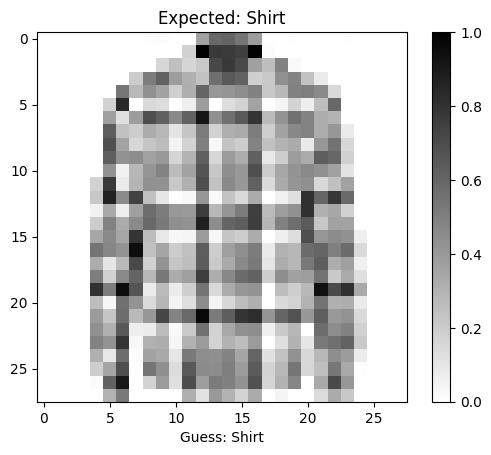

In [48]:
def get_number():
    while True:

      num = input("Pick a number: ")
      if num.isdigit():
        num = int(num)
        if 0 <= num <= 1000:
         return int(num)
      else:
        print("Try again...")





def show_image(img, label, guess):
    plt.figure()
    plt.imshow(img, cmap=plt.cm.binary)
    plt.title("Expected: " + label)
    plt.xlabel("Guess: " + guess)
    plt.colorbar()
    plt.grid(False)
    plt.show()

def predict(model, image, correct_label):


  class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
  'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
  prediction = model.predict(np.array([image]))
  predicted_class = class_names[np.argmax(prediction)]

  show_image(image, class_names[correct_label], predicted_class)



num = get_number()
image = test_images[num]
label = test_labels[num]
predict(model, image, label)

In [49]:
model.save('fashmnistmodel.keras')